# EDA de Banking77 para Clustering

Este notebook analiza Banking77 con foco en preparar un pipeline de clustering para FAQs/intents similares.

Objetivos:
- Evaluar calidad textual (vacios, duplicados, longitud).
- Entender distribucion por labels e indicios de complejidad lexica.
- Diagnosticar representaciones (BoW/TF-IDF) antes de clusterizar.
- Exportar un subconjunto con 8 labels similares para clustering conjunto.

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 120)

In [2]:
# Resolver root y cargar DatasetLoader local
import importlib.util

CANDIDATE_ROOT = Path.cwd().resolve()
if CANDIDATE_ROOT.name == "notebooks" and CANDIDATE_ROOT.parent.name == "validation":
    ROOT = CANDIDATE_ROOT.parent.parent
else:
    ROOT = next(
        (p for p in [CANDIDATE_ROOT, *CANDIDATE_ROOT.parents] if (p / "validation" / "datasets.py").exists()),
        CANDIDATE_ROOT,
    )

def _load_local_module(module_name: str, file_path: Path):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    assert spec is not None and spec.loader is not None
    spec.loader.exec_module(module)
    return module

datasets_module = _load_local_module("tfg_validation_datasets", ROOT / "validation" / "datasets.py")
DatasetLoader = datasets_module.DatasetLoader

EDA_DIR = ROOT / "validation" / "results" / "banking77_eda"
TABLES_DIR = EDA_DIR / "tables"
FIGURES_DIR = EDA_DIR / "figures"
for p in [EDA_DIR, TABLES_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"Resultados EDA: {EDA_DIR}")

ROOT: /home/gabriel/clase/TFG/TFG-Chatbot
Resultados EDA: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/banking77_eda


/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Carga Banking77 completo
loader = DatasetLoader()
df = loader.load_banking77(limit=20000).copy()
df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(str)

print(df.shape)
print("Labels unicas:", df["label"].nunique())
df.head()

Loading Banking77...
Loaded mteb/banking77 (default) split=train
(9993, 2)
Labels unicas: 77


,text,label
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival
2,I have been waiting over a week. Is the card still coming?,card_arrival
3,Can I track my card while it is in the process of delivery?,card_arrival
4,"How do I know if I will get my card, or if it is lost?",card_arrival


In [4]:
# Exportar todas las preguntas del dataset a archivo
questions_path = TABLES_DIR / "banking77_all_questions.csv"
df[["text", "label"]].rename(columns={"text": "question"}).to_csv(
    questions_path, index=False, encoding="utf-8"
 )

print(f"Archivo generado: {questions_path}")
df[["text", "label"]].head()

Archivo generado: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/banking77_eda/tables/banking77_all_questions.csv


,text,label
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival
2,I have been waiting over a week. Is the card still coming?,card_arrival
3,Can I track my card while it is in the process of delivery?,card_arrival
4,"How do I know if I will get my card, or if it is lost?",card_arrival


In [5]:
# Calidad basica
quality = {
    "n_rows": len(df),
    "n_labels": int(df["label"].nunique()),
    "n_missing_text": int(df["text"].isna().sum()),
    "n_empty_or_blank": int((df["text"].str.strip().str.len() == 0).sum()),
    "n_duplicates_exact": int(df.duplicated(subset=["text"]).sum()),
    "dup_rate": float(df.duplicated(subset=["text"]).mean()),
}

df_quality = pd.DataFrame([quality])
df_quality.to_csv(TABLES_DIR / "quality_summary.csv", index=False)
df_quality

,n_rows,n_labels,n_missing_text,n_empty_or_blank,n_duplicates_exact,dup_rate
0,9993,77,0,0,0,0.0


In [6]:
# Limpieza minima para EDA de clustering
df_clean = df.dropna(subset=["text"]).copy()
df_clean["text"] = df_clean["text"].str.strip()
df_clean = df_clean[df_clean["text"].str.len() > 0]
df_clean = df_clean.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Antes:", len(df), " | Despues:", len(df_clean))
df_clean.head()

Antes: 9993  | Despues: 9993


,text,label
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival
2,I have been waiting over a week. Is the card still coming?,card_arrival
3,Can I track my card while it is in the process of delivery?,card_arrival
4,"How do I know if I will get my card, or if it is lost?",card_arrival


In [7]:
# Longitud en caracteres y tokens aproximados
token_pattern = re.compile(r"\w+", flags=re.UNICODE)
df_clean["char_len"] = df_clean["text"].str.len()
df_clean["tok_len"] = df_clean["text"].apply(lambda t: len(token_pattern.findall(t.lower())))

desc = df_clean[["char_len", "tok_len"]].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).T
desc.to_csv(TABLES_DIR / "length_describe.csv")
desc

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
char_len,9993.0,59.500751,40.873448,13.0,29.0,36.0,47.0,64.0,110.0,152.0,433.0
tok_len,9993.0,12.260082,8.124439,3.0,6.0,8.0,10.0,13.0,22.0,30.0,84.0


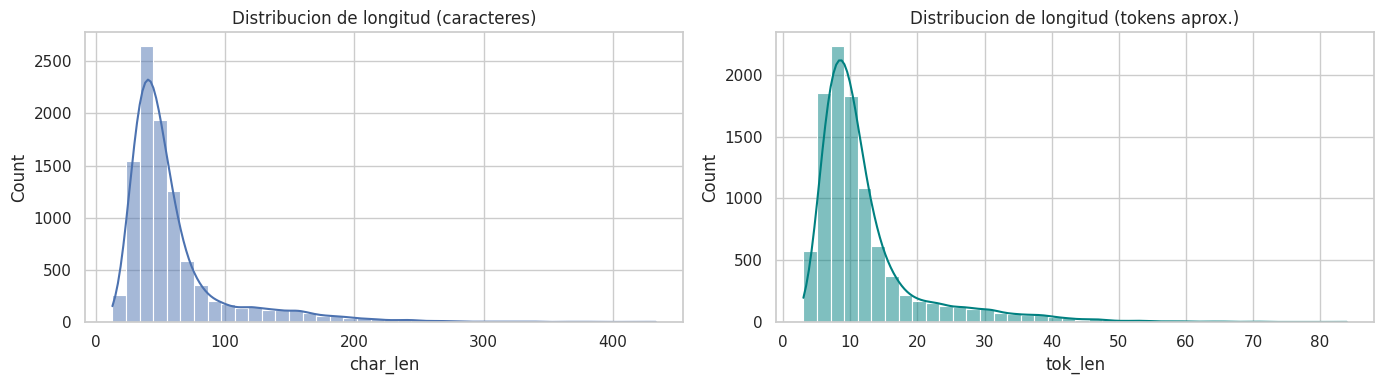

In [8]:
# Distribuciones de longitud
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_clean["char_len"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribucion de longitud (caracteres)")

sns.histplot(df_clean["tok_len"], bins=40, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Distribucion de longitud (tokens aprox.)")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "length_distributions.png", dpi=180, bbox_inches="tight")
plt.show()

In [9]:
# Frecuencias de terminos (unigramas y bigramas)
texts = df_clean["text"].tolist()

cv_uni = CountVectorizer(stop_words="english", ngram_range=(1, 1), min_df=2, max_df=0.9)
X_uni = cv_uni.fit_transform(texts)
freq_uni = np.asarray(X_uni.sum(axis=0)).ravel()
top_uni_idx = np.argsort(freq_uni)[::-1][:30]
df_top_uni = pd.DataFrame({
    "term": np.array(cv_uni.get_feature_names_out())[top_uni_idx],
    "count": freq_uni[top_uni_idx],
})

cv_bi = CountVectorizer(stop_words="english", ngram_range=(2, 2), min_df=2, max_df=0.9)
X_bi = cv_bi.fit_transform(texts)
freq_bi = np.asarray(X_bi.sum(axis=0)).ravel()
top_bi_idx = np.argsort(freq_bi)[::-1][:30]
df_top_bi = pd.DataFrame({
    "term": np.array(cv_bi.get_feature_names_out())[top_bi_idx],
    "count": freq_bi[top_bi_idx],
})

df_top_uni.to_csv(TABLES_DIR / "top_unigrams.csv", index=False)
df_top_bi.to_csv(TABLES_DIR / "top_bigrams.csv", index=False)

display(df_top_uni.head(15))
display(df_top_bi.head(15))

,term,count
0,card,2681
1,account,1352
2,money,1132
3,transfer,1083
4,payment,751
5,need,697
6,cash,691
7,exchange,549
8,charged,529
9,atm,482


,term,count
0,exchange rate,293
1,new card,226
2,card payment,202
3,virtual card,181
4,cash withdrawal,165
5,money account,148
6,transfer money,118
7,long does,109
8,direct debit,102
9,extra fee,97


In [10]:
# Diagnostico de representacion BoW/TF-IDF
bow = CountVectorizer(max_features=4000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf = TfidfVectorizer(max_features=4000, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)

X_bow = bow.fit_transform(texts)
X_tfidf = tfidf.fit_transform(texts)

def matrix_stats(name: str, X) -> dict:
    n, d = X.shape
    nnz = X.nnz
    sparsity = 1.0 - (nnz / (n * d))
    avg_nnz_row = nnz / n
    return {
        "representation": name,
        "n_samples": n,
        "n_features": d,
        "nnz": int(nnz),
        "sparsity": float(sparsity),
        "avg_nnz_per_doc": float(avg_nnz_row),
    }

df_repr = pd.DataFrame([matrix_stats("bow", X_bow), matrix_stats("tfidf", X_tfidf)])
df_repr.to_csv(TABLES_DIR / "representation_stats.csv", index=False)
df_repr

,representation,n_samples,n_features,nnz,sparsity,avg_nnz_per_doc
0,bow,9993,4000,169008,0.995772,16.912639
1,tfidf,9993,4000,169008,0.995772,16.912639


In [11]:
# Heuristica para rango de k con silhouette (muestra)
sample_n = min(3000, len(df_clean))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(df_clean), size=sample_n, replace=False)
X_sample = X_tfidf[sample_idx]

k_values = list(range(2, 21))
rows = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    asw = silhouette_score(X_sample, labels, metric="cosine")
    rows.append({"k": k, "asw_cosine": float(asw)})

df_k_scan = pd.DataFrame(rows)
df_k_scan.to_csv(TABLES_DIR / "k_scan_tfidf_cosine_sample.csv", index=False)
df_k_scan

,k,asw_cosine
0,2,0.014553
1,3,0.018269
2,4,0.019641
3,5,0.022420
4,6,0.023516
5,7,0.025343
6,8,0.028834
7,9,0.027386
8,10,0.029989
9,11,0.033374


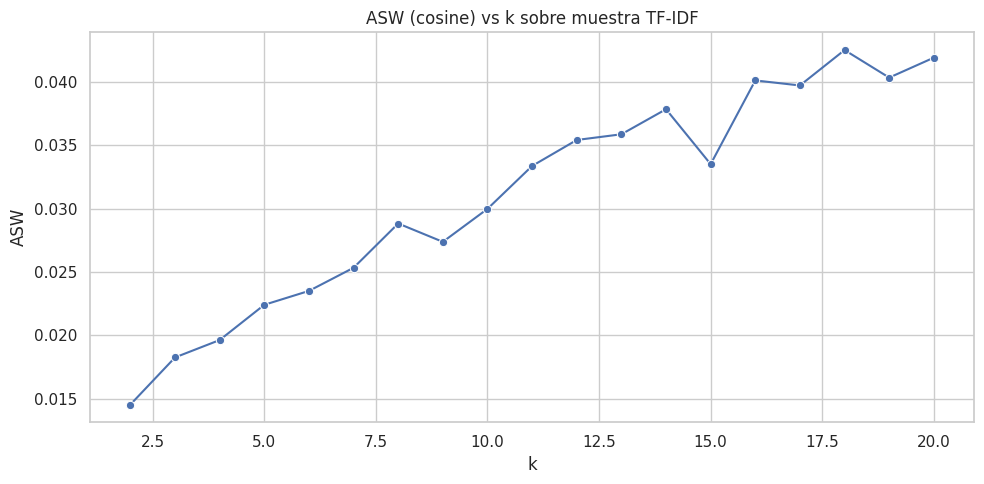

In [12]:
# Visualizacion del barrido de k
ax = sns.lineplot(data=df_k_scan, x="k", y="asw_cosine", marker="o")
ax.set_title("ASW (cosine) vs k sobre muestra TF-IDF")
ax.set_xlabel("k")
ax.set_ylabel("ASW")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "k_scan_tfidf_cosine_sample.png", dpi=180, bbox_inches="tight")
plt.show()

In [14]:
# Seleccion de 8 labels similares para clustering conjunto
available_labels = sorted(df_clean["label"].unique())

# Elegimos un bloque coherente de incidencias relacionadas con tarjeta y extracciones.
candidate_pools = [
    [
        "beneficiary_not_allowed",
        "cash_withdrawal",
        "cash_withdrawal_charge",
        "cash_withdrawal_not_recognised",
        "cash_withdrawal_not_recognized",
        "card_arrival",
        "card_delivery_estimate",
        "card_not_working",
        "card_linking",
        "card_payment_not_recognised",
        "card_payment_not_recognized",
        "cash_withdrawal_by_card",
        "cash_withdrawal_card",
    ],
    [lbl for lbl in available_labels if "card" in lbl],
    [lbl for lbl in available_labels if "cash" in lbl or "withdraw" in lbl],
]

SIMILAR_LABELS = []
for pool in candidate_pools:
    for lbl in pool:
        if lbl in available_labels and lbl not in SIMILAR_LABELS:
            SIMILAR_LABELS.append(lbl)
        if len(SIMILAR_LABELS) == 8:
            break
    if len(SIMILAR_LABELS) == 8:
        break

if len(SIMILAR_LABELS) < 8:
    raise ValueError(
        f"No se pudieron seleccionar 8 labels similares. Disponibles: {available_labels[:20]} ..."
    )

df_subset = df_clean[df_clean["label"].isin(SIMILAR_LABELS)].copy().reset_index(drop=True)
subset_counts = df_subset["label"].value_counts().rename_axis("label").reset_index(name="count")

subset_path = TABLES_DIR / "banking77_similar8_subset.csv"
subset_counts_path = TABLES_DIR / "banking77_similar8_subset_label_distribution.csv"
selected_labels_path = TABLES_DIR / "banking77_similar8_selected_labels.csv"
df_subset.to_csv(subset_path, index=False, encoding="utf-8")
subset_counts.to_csv(subset_counts_path, index=False, encoding="utf-8")
pd.DataFrame({"label": SIMILAR_LABELS}).to_csv(selected_labels_path, index=False, encoding="utf-8")

print("Labels seleccionados:", SIMILAR_LABELS)
print(f"Subset exportado en: {subset_path}")
print(f"Distribucion de labels en: {subset_counts_path}")
print(f"Lista de labels en: {selected_labels_path}")
print(f"Filas en subset: {len(df_subset)} | labels: {df_subset['label'].nunique()}")
display(subset_counts)

Labels seleccionados: ['beneficiary_not_allowed', 'cash_withdrawal_charge', 'cash_withdrawal_not_recognised', 'card_arrival', 'card_delivery_estimate', 'card_not_working', 'card_linking', 'card_payment_not_recognised']
Subset exportado en: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/banking77_eda/tables/banking77_similar8_subset.csv
Distribucion de labels en: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/banking77_eda/tables/banking77_similar8_subset_label_distribution.csv
Lista de labels en: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/banking77_eda/tables/banking77_similar8_selected_labels.csv
Filas en subset: 1176 | labels: 8


,label,count
0,cash_withdrawal_charge,177
1,card_payment_not_recognised,168
2,cash_withdrawal_not_recognised,160
3,beneficiary_not_allowed,156
4,card_arrival,153
5,card_linking,139
6,card_delivery_estimate,112
7,card_not_working,111


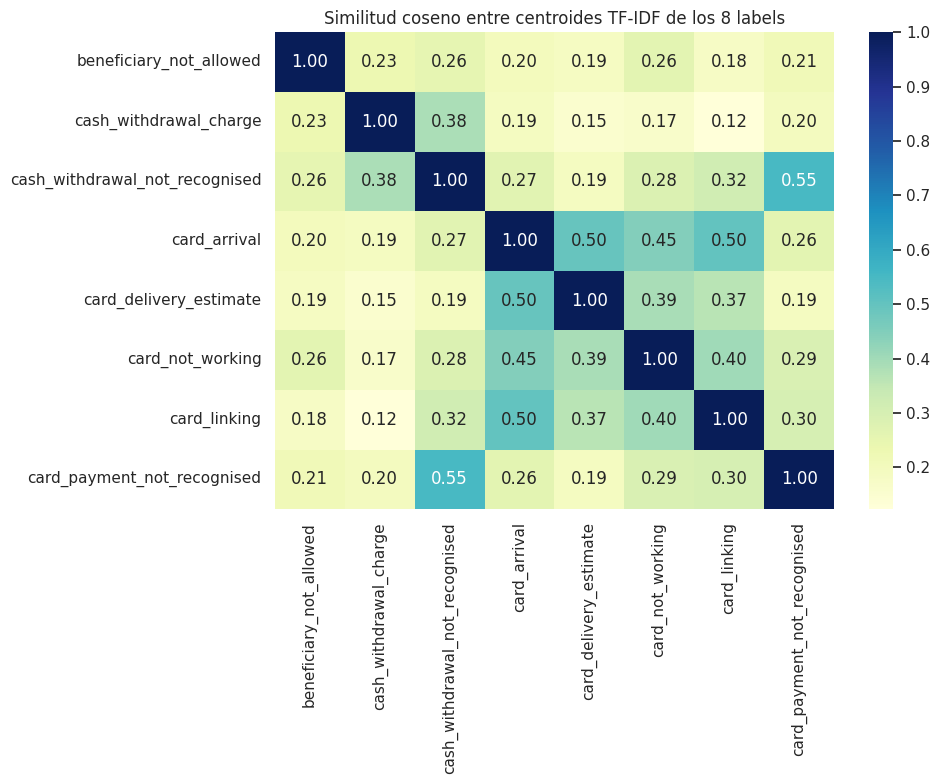

In [15]:
# Chequeo rapido de cercania semantica entre los 8 labels con centroides TF-IDF
from sklearn.metrics.pairwise import cosine_similarity

subset_texts = df_subset["text"].tolist()
subset_tfidf = TfidfVectorizer(max_features=4000, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)
X_subset = subset_tfidf.fit_transform(subset_texts)

label_to_rows = {}
for lbl in SIMILAR_LABELS:
    idx = np.where(df_subset["label"].values == lbl)[0]
    label_to_rows[lbl] = idx

centroids = []
for lbl in SIMILAR_LABELS:
    rows = label_to_rows[lbl]
    centroids.append(np.asarray(X_subset[rows].mean(axis=0)).ravel())

centroids = np.vstack(centroids)
sim = cosine_similarity(centroids)
sim_df = pd.DataFrame(sim, index=SIMILAR_LABELS, columns=SIMILAR_LABELS)
sim_df.to_csv(TABLES_DIR / "banking77_similar8_centroid_cosine_similarity.csv", encoding="utf-8")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title("Similitud coseno entre centroides TF-IDF de los 8 labels")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "banking77_similar8_centroid_similarity.png", dpi=180, bbox_inches="tight")
plt.show()

## Resultado principal del EDA

El subset final para el experimento de clustering se exporta en:
- validation/results/banking77_eda/tables/banking77_similar8_subset.csv

Este archivo contiene todas las preguntas de los 8 labels similares definidos en SIMILAR_LABELS.